#  Решение задачи регрессии при помощи пакета `torch`. Метрики.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.html
* https://pytorch.org/docs/stable/optim.html
* https://github.com/Lightning-AI/torchmetrics
* https://pytorch.org/docs/stable/generated/torch.no_grad.html
* https://pytorch-lightning.readthedocs.io/en/2.1.2/pytorch/ecosystem/metrics.html#torchmetrics

## Задачи для совместного разбора

In [ ]:
pip install torchtyping

  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.4
    Uninstalling typeguard-4.4.4:
      Successfully uninstalled typeguard-4.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked
import torch as th
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from typing import TypeVar

Scalar = TensorType[()]
patch_typeguard()

1\. Используя реализацию из `torch.nn`, решите задачу регрессии. Для расчета градиентов воспользуйтесь возможностями по автоматическому дифференцированию `torch`. В качестве функции потерь используйте собственную реализацию MSE. Для настройки весов реализуйте пакетный градиентный спуск с использованием `torch.optim.SGD`.

In [ ]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y)

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self, input_dim):
    super(LinearRegression, self).__init__()
    self.linear = nn.Linear(input_dim, 1)

  def forward(self, x):
    return self.linear(x).squeeze()

def mse_loss(y_pred, y_true):
    return th.mean((y_pred - y_true) ** 2)

In [ ]:
input_dim = X.shape[1]
n_epochs = 1000
learning_rate = 0.001
batch_size = 32

model = LinearRegression(input_dim)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

dataset = th.utils.data.TensorDataset(X, y)
dataloader = th.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

model.train()
for epoch in range(n_epochs):
  total_loss = 0
  for batch_X, batch_y in dataloader:
    y_pred = model(batch_X)

    loss = mse_loss(y_pred, batch_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch + 1) % 100 == 0:
          avg_loss = total_loss / len(dataloader)
          print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}')

model.eval()
with th.no_grad():
  y_pred_all = model(X)
  final_loss = mse_loss(y_pred_all, y)

  learned_coef = model.linear.weight.detach().numpy().flatten()

final_loss.item(), learned_coef


Epoch [100/1000], Loss: 2213.3237
Epoch [200/1000], Loss: 426.3860
Epoch [300/1000], Loss: 103.6835
Epoch [400/1000], Loss: 33.5947
Epoch [500/1000], Loss: 9.7532
Epoch [600/1000], Loss: 2.0833
Epoch [700/1000], Loss: 0.5874
Epoch [800/1000], Loss: 0.1491
Epoch [900/1000], Loss: 0.0416
Epoch [1000/1000], Loss: 0.0177


(0.0138360895216465,
 array([ 5.633043, 86.416756, 27.367561, 41.362404], dtype=float32))

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию полносвязного слоя из `torch.nn` решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Для создания модели опишите класс `SineModel`.

Предлагаемая архитектура нейронной сети:
1. Полносвязный слой с 100 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).

Выведите график изменения значения функции потерь в процессе обучения. Логику расчета значения функции потерь на уровне эпохи реализуйте самостоятельно.

- [ ] Проверено на семинаре

In [ ]:
TensorType = TypeVar("TensorType")

In [ ]:
import torch

X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [ ]:
import torch.nn as nn
class SineModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.layer1 = nn.Linear(n_features, n_hidden)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(n_hidden, n_out)

    def forward(self, X: TensorType["batch", "n_features"]) -> TensorType["batch", 1]:
        h1 = self.layer1(X)
        h2 = self.relu(h1)
        y_pred = self.layer2(h2)
        return y_pred


In [ ]:
n_features = X.size()[1]
n_hidden = X.size()[0]
n_out = 1
learning_rate = 0.01
n_epoch = 2000
batch_size = 32

In [ ]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
model = SineModel(n_features, n_hidden, n_out)
mse_loss = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

predict = []
losses = []
s_epochs = [0, n_epoch // 2, n_epoch - 1]

model.train()
for epoch in range(n_epoch):
  total_loss = 0
  n_batches = 0

  for batch_X, batch_y in dataloader:
      y_pred = model(batch_X)
      loss = mse_loss(y_pred, batch_y)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      total_loss += loss.item()
      n_batches += 1

  avg_loss = total_loss / n_batches
  losses.append(avg_loss)

  if epoch in s_epochs:
        model.eval()
        with torch.no_grad():
            y_pred = model(X)
            predict.append((epoch, y_pred.clone()))
        model.train()
  if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{n_epoch}], Loss: {avg_loss:.6f}')

model.eval()
with torch.no_grad():
  y_pred_f = model(X)
  final_loss = mse_loss(y_pred_f, y)
  print(f'\nFinal MSE Loss: {final_loss.item():.6f}')


Epoch [200/2000], Loss: 0.177833
Epoch [400/2000], Loss: 0.145191
Epoch [600/2000], Loss: 0.134523
Epoch [800/2000], Loss: 0.113657
Epoch [1000/2000], Loss: 0.098673
Epoch [1200/2000], Loss: 0.073947
Epoch [1400/2000], Loss: 0.055156
Epoch [1600/2000], Loss: 0.047940
Epoch [1800/2000], Loss: 0.034565
Epoch [2000/2000], Loss: 0.024974

Final MSE Loss: 0.027138


In [ ]:
import matplotlib.pyplot as plt

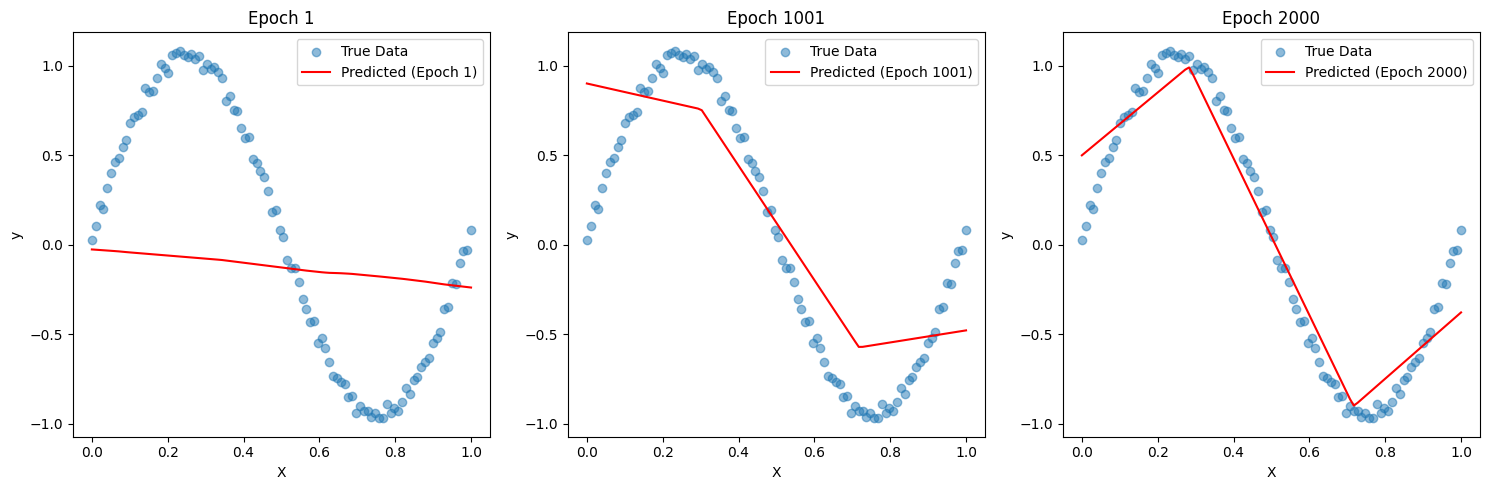

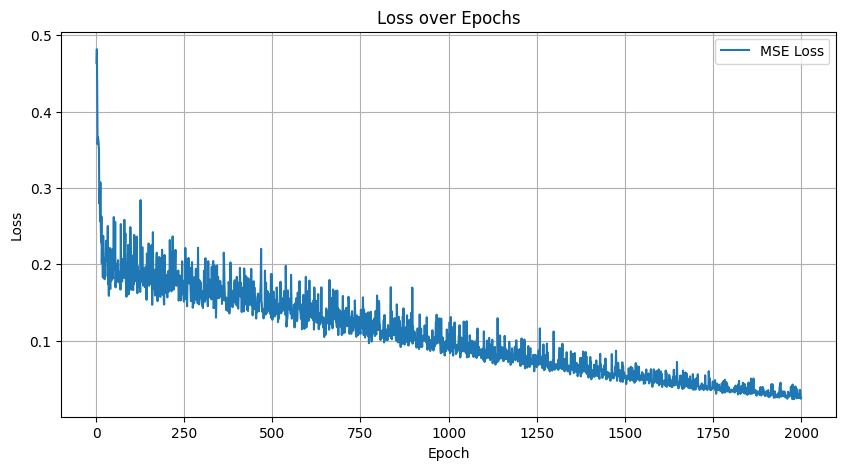

In [ ]:
plt.figure(figsize=(15, 5))
for i, (epoch, y_pred) in enumerate(predict):
    plt.subplot(1, len(predict), i + 1)
    plt.scatter(X.numpy(), y.numpy(), label='True Data', alpha=0.5)
    plt.plot(X.numpy(), y_pred.numpy(), label=f'Predicted (Epoch {epoch+1})', color='red')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Epoch {epoch+1}')
    plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epoch + 1), losses, label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

<p class="task" id="2"></p>

2\. Повторите решение задачи 1, изменив модель. Для создания модели создайте объект класса `nn.Sequential`.

Предлагаемая архитектура нейронной сети:
1. Полносвязный слой с 50 нейронами
2. Активация Tanh
3. Полносвязный слой с 1 нейроном

- [ ] Проверено на семинаре

In [ ]:
import torch

X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [ ]:
model = nn.Sequential(nn.Linear(1, 50), nn.Tanh(), nn.Linear(50,1))

In [ ]:
learning_rate = 0.1
n_epoch = 2000
batch_size = 32

In [ ]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
mse_loss = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

predict = []
losses = []
s_epochs = [0, n_epoch // 2, n_epoch - 1]

model.train()
for epoch in range(n_epoch):
  total_loss = 0
  n_batches = 0

  for batch_X, batch_y in dataloader:
      y_pred = model(batch_X)
      loss = mse_loss(y_pred, batch_y)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      total_loss += loss.item()
      n_batches += 1

  avg_loss = total_loss / n_batches
  losses.append(avg_loss)

  if epoch in s_epochs:
        model.eval()
        with torch.no_grad():
            y_pred = model(X)
            predict.append((epoch, y_pred.clone()))
        model.train()
  if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{n_epoch}], Loss: {avg_loss:.6f}')

model.eval()
with torch.no_grad():
  y_pred_f = model(X)
  final_loss = mse_loss(y_pred_f, y)
  print(f'\nFinal MSE Loss: {final_loss.item():.6f}')


Epoch [200/2000], Loss: 0.215320
Epoch [400/2000], Loss: 0.114586
Epoch [600/2000], Loss: 0.007064
Epoch [800/2000], Loss: 0.004764
Epoch [1000/2000], Loss: 0.007002
Epoch [1200/2000], Loss: 0.003848
Epoch [1400/2000], Loss: 0.003417
Epoch [1600/2000], Loss: 0.008133
Epoch [1800/2000], Loss: 0.005689
Epoch [2000/2000], Loss: 0.004058

Final MSE Loss: 0.008936


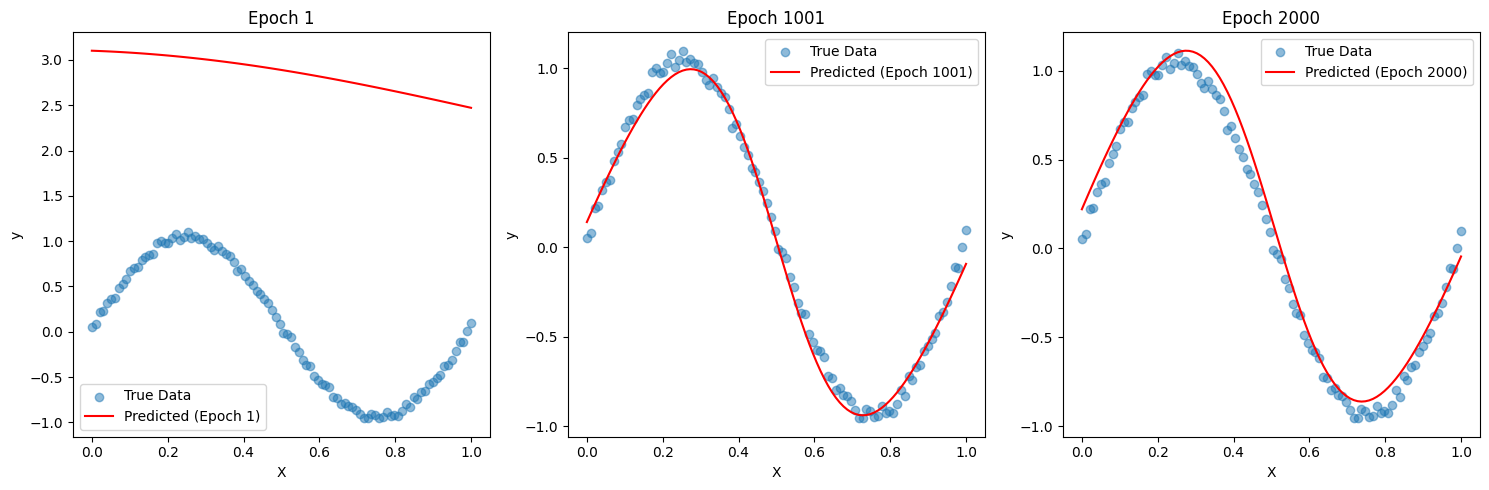

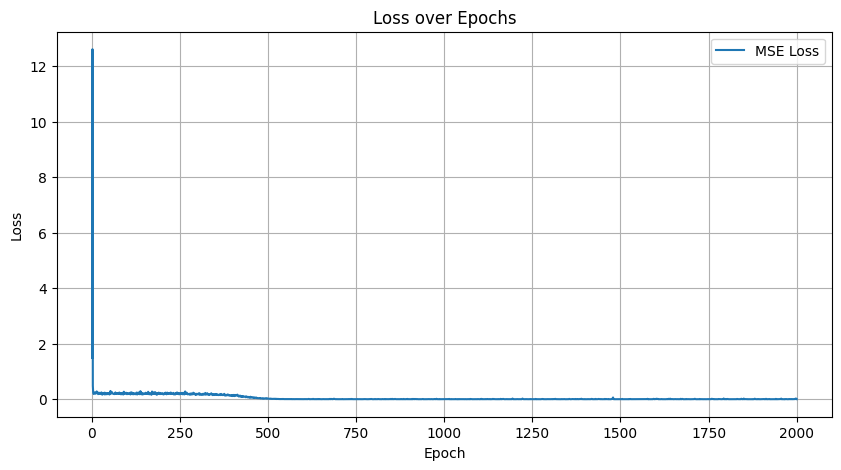

In [ ]:
plt.figure(figsize=(15, 5))
for i, (epoch, y_pred) in enumerate(predict):
    plt.subplot(1, len(predict), i + 1)
    plt.scatter(X.numpy(), y.numpy(), label='True Data', alpha=0.5)
    plt.plot(X.numpy(), y_pred.numpy(), label=f'Predicted (Epoch {epoch+1})', color='red')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Epoch {epoch+1}')
    plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epoch + 1), losses, label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

<p class="task" id="3"></p>

3\. Используя реализацию полносвязного слоя из `torch.nn`, решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Перенесите вычисления на GPU и сравните время обучения с и без использования GPU. Решение должно корректно работать в случае отсутствия GPU без дополнительных изменений в коде.

- [ ] Проверено на семинаре

In [ ]:
from sklearn.datasets import make_regression
import torch as th
import time

X, y, coef = make_regression(
    n_samples=10000,
    n_features=10,
    n_informative=6,
    coef=True,
    bias=0.5,
    random_state=42
)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [ ]:
num_epochs = 1000
batch_size = 64
learning_rate = 0.01

print("\nTraining on CPU...")
model_cpu = nn.Sequential( nn.Linear(10, 50), nn.Tanh(), nn.Linear(50, 1)).to('cpu')

nn.init.xavier_uniform_(model_cpu[0].weight)
nn.init.xavier_uniform_(model_cpu[2].weight)

X_cpu = X.to('cpu')
y_cpu = y.to('cpu')

dataset_cpu = TensorDataset(X_cpu, y_cpu)
dataloader_cpu = DataLoader(dataset_cpu, batch_size=batch_size, shuffle=True)

criterion = nn.MSELoss()
optimizer_cpu = optim.SGD(model_cpu.parameters(), lr=learning_rate)

start_time_cpu = time.perf_counter()

model_cpu.train()
losses_cpu = []
for epoch in range(num_epochs):
    total_loss = 0
    num_batches = 0
    for batch_X, batch_y in dataloader_cpu:
        y_pred = model_cpu(batch_X)
        loss = criterion(y_pred, batch_y)
        optimizer_cpu.zero_grad()
        loss.backward()
        optimizer_cpu.step()
        total_loss += loss.item()
        num_batches += 1
    avg_loss = total_loss / num_batches
    losses_cpu.append(avg_loss)
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')

model_cpu.eval()
with th.no_grad():
    y_pred_final = model_cpu(X_cpu)
    final_loss_cpu = criterion(y_pred_final, y_cpu)
print(f'\nFinal MSE Loss (CPU): {final_loss_cpu.item():.6f}')

time_cpu = time.perf_counter() - start_time_cpu
print(f'Training time on CPU: {time_cpu:.2f} seconds')


Training on CPU...
Epoch [100/1000], Loss: 0.330924
Epoch [200/1000], Loss: 0.037819
Epoch [300/1000], Loss: 0.057647
Epoch [400/1000], Loss: 0.028090
Epoch [500/1000], Loss: 0.006716
Epoch [600/1000], Loss: 0.003023
Epoch [700/1000], Loss: 0.014417
Epoch [800/1000], Loss: 0.040999
Epoch [900/1000], Loss: 0.020516
Epoch [1000/1000], Loss: 0.004205

Final MSE Loss (CPU): 0.017128
Training time on CPU: 152.97 seconds


In [ ]:
if th.cuda.is_available():
    print("\nTraining on GPU...")

    model_gpu = nn.Sequential(nn.Linear(10, 50), nn.Tanh(), nn.Linear(50, 1)).to('cuda')

    nn.init.xavier_uniform_(model_gpu[0].weight)
    nn.init.xavier_uniform_(model_gpu[2].weight)

    X_gpu = X.to('cuda')
    y_gpu = y.to('cuda')

    dataset_gpu = TensorDataset(X_gpu, y_gpu)
    dataloader_gpu = DataLoader(dataset_gpu, batch_size=batch_size, shuffle=True)

    optimizer_gpu = optim.SGD(model_gpu.parameters(), lr=learning_rate)

    start_time_gpu = time.perf_counter()

    model_gpu.train()
    losses_gpu = []
    for epoch in range(num_epochs):
        total_loss = 0
        num_batches = 0
        for batch_X, batch_y in dataloader_gpu:
            y_pred = model_gpu(batch_X)
            loss = criterion(y_pred, batch_y)
            optimizer_gpu.zero_grad()
            loss.backward()
            optimizer_gpu.step()
            total_loss += loss.item()
            num_batches += 1
        avg_loss = total_loss / num_batches
        losses_gpu.append(avg_loss)
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')

    model_gpu.eval()
    with th.no_grad():
        y_pred_final = model_gpu(X_gpu)
        final_loss_gpu = criterion(y_pred_final, y_gpu)
    print(f'\nFinal MSE Loss (GPU): {final_loss_gpu.item():.6f}')

    time_gpu = time.perf_counter() - start_time_gpu
    print(f'Training time on GPU: {time_gpu:.2f} seconds')

    print(f'\nTime comparison: CPU = {time_cpu:.2f}s, GPU = {time_gpu:.2f}s')
    print(f'GPU speedup: {time_cpu / time_gpu:.2f}x')
else:
    print("\nGPU not available, skipping GPU training.")


Training on GPU...
Epoch [100/1000], Loss: 0.200726
Epoch [200/1000], Loss: 0.272922
Epoch [300/1000], Loss: 0.015499
Epoch [400/1000], Loss: 0.014188
Epoch [500/1000], Loss: 0.036314
Epoch [600/1000], Loss: 0.019093
Epoch [700/1000], Loss: 0.032517
Epoch [800/1000], Loss: 0.008503
Epoch [900/1000], Loss: 0.006881
Epoch [1000/1000], Loss: 0.097953

Final MSE Loss (GPU): 0.150764
Training time on GPU: 231.14 seconds

Time comparison: CPU = 152.97s, GPU = 231.14s
GPU speedup: 0.66x


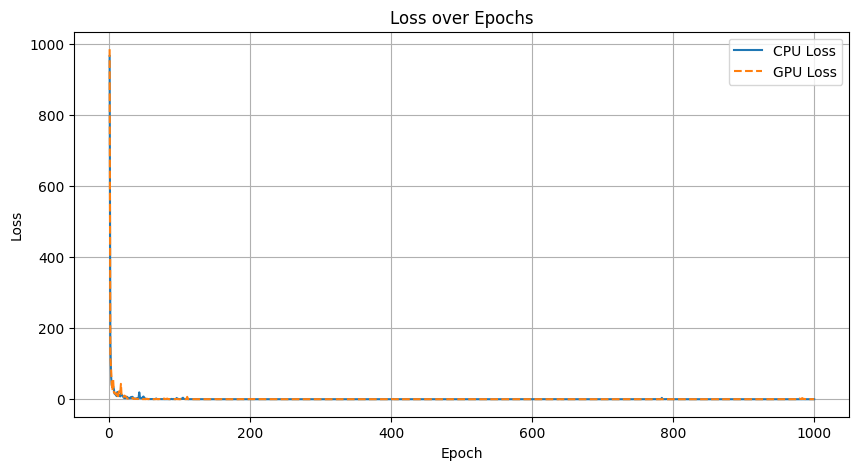

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses_cpu, label='CPU Loss')
if th.cuda.is_available():
    plt.plot(range(1, num_epochs + 1), losses_gpu, label='GPU Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

<p class="task" id="4"></p>

4\. Повторите решение задач 1-2, используя для расчета значения функции потерь за эпоху метрику `MeanMetric` из пакета `torchmetrics`. Добавьте в цикл обучения расчет метрики $R^2$ (воспользуйтесь реализацией из `torchmetrics`). Выведите на экран график изменения значения функции потерь и метрики $R^2$ по эпохам в процессе обучения.

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 17.3 MB/s eta 0:00:00


In [ ]:
from torchmetrics import MeanMetric, R2Score
import time

In [ ]:
X = th.linspace(0, 1, 100).view(-1, 1)
y = th.sin(2 * th.pi * X) + 0.1 * th.rand(X.size())

In [ ]:
n_features = X.size()[1]
n_hidden = X.size()[0]
n_out = 1
learning_rate = 0.01
n_epoch = 2000
batch_size = 32

In [ ]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
model = SineModel(n_features, n_hidden, n_out)
mse_loss = nn.MSELoss()
mean_metric = MeanMetric()
r2_metric = R2Score()
optimizer = optim.SGD(model.parameters(), lr = learning_rate)


losses = []
r2_scores = []
start_time = time.perf_counter()

model.train()
for epoch in range(n_epoch):
  mean_metric.reset()
  r2_metric.reset()

  for batch_X, batch_y in dataloader:
      y_pred = model(batch_X)
      loss = mse_loss(y_pred, batch_y)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      mean_metric.update(loss)
      r2_metric.update(y_pred, batch_y)

  avg_loss = mean_metric.compute().item()
  r2_score = r2_metric.compute().item()
  losses.append(avg_loss)
  r2_scores.append(r2_score)

  if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{n_epoch}], Loss: {avg_loss:.6f}')

model.eval()
with th.no_grad():
  y_pred_f = model(X)
  final_loss = mse_loss(y_pred_f, y)
  final_r2 = r2_metric(y_pred_f, y)
print(f'\nFinal MSE Loss: {final_loss:.6f}, Final R^2: {final_r2:.6f}')

training_time = time.perf_counter() - start_time
print(f'Training time: {training_time:.2f} seconds')


Epoch [200/2000], Loss: 0.165114
Epoch [400/2000], Loss: 0.135586
Epoch [600/2000], Loss: 0.132325
Epoch [800/2000], Loss: 0.083004
Epoch [1000/2000], Loss: 0.068111
Epoch [1200/2000], Loss: 0.058880
Epoch [1400/2000], Loss: 0.041979
Epoch [1600/2000], Loss: 0.039997
Epoch [1800/2000], Loss: 0.031244
Epoch [2000/2000], Loss: 0.020009

Final MSE Loss: 0.019936, Final R^2: 0.960301
Training time: 10.87 seconds


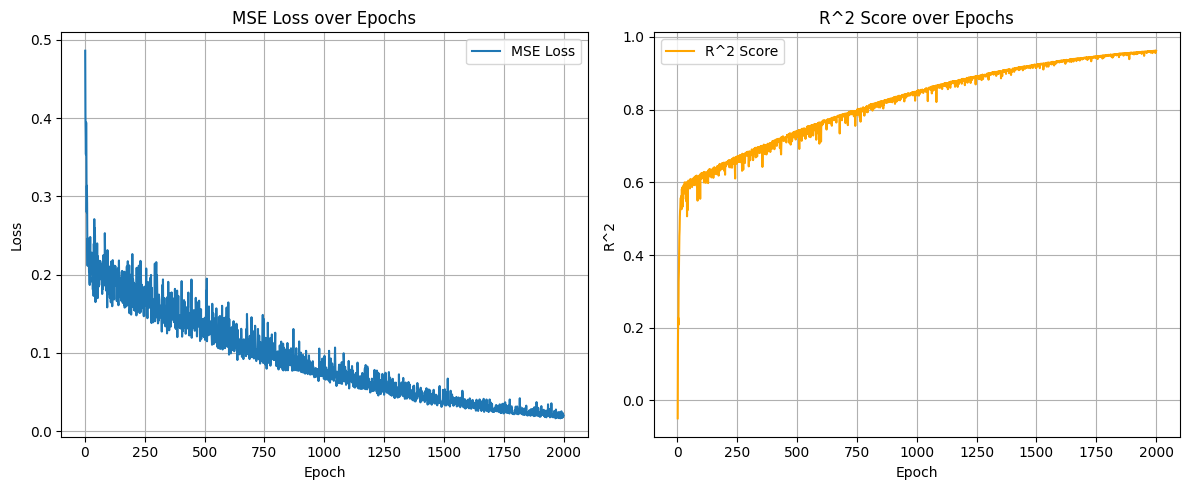

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 2001), losses, label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MSE Loss over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 2001), r2_scores, label='R^2 Score', color='orange')
plt.xlabel('Epoch')
plt.ylabel('R^2')
plt.title('R^2 Score over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 2

In [ ]:
X = th.linspace(0, 1, 100).view(-1, 1)
y = th.sin(2 * th.pi * X) + 0.1 * th.rand(X.size())

In [ ]:
model = nn.Sequential(nn.Linear(1, 50), nn.Tanh(), nn.Linear(50,1))

In [ ]:
learning_rate = 0.1
n_epoch = 2000
batch_size = 32

In [ ]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
mse_loss = nn.MSELoss()
mean_metric = MeanMetric()
r2_metric = R2Score()
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

losses = []
r2_scores = []

start_time = time.perf_counter()
model.train()
for epoch in range(n_epoch):
  mean_metric.reset()
  r2_metric.reset()
  for batch_X, batch_y in dataloader:
      y_pred = model(batch_X)
      loss = mse_loss(y_pred, batch_y)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      mean_metric.update(loss)
      r2_metric.update(y_pred, batch_y)

  avg_loss = mean_metric.compute().item()
  r2_score = r2_metric.compute().item()
  losses.append(avg_loss)
  r2_scores.append(r2_score)

  if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{n_epoch}], Loss: {avg_loss:.6f}')

model.eval()
with th.no_grad():
  y_pred_f = model(X)
  final_loss = mse_loss(y_pred_f, y)
  final_r2 = r2_metric(y_pred_f, y)
print(f'\nFinal MSE Loss: {final_loss:.6f}, Final R^2: {final_r2:.6f}')

training_time = time.perf_counter() - start_time
print(f'Training time: {training_time:.2f} seconds')

Epoch [200/2000], Loss: 0.185205
Epoch [400/2000], Loss: 0.066643
Epoch [600/2000], Loss: 0.004261
Epoch [800/2000], Loss: 0.004760
Epoch [1000/2000], Loss: 0.004543
Epoch [1200/2000], Loss: 0.003617
Epoch [1400/2000], Loss: 0.002908
Epoch [1600/2000], Loss: 0.003084
Epoch [1800/2000], Loss: 0.007682
Epoch [2000/2000], Loss: 0.003288

Final MSE Loss: 0.003597, Final R^2: 0.992799
Training time: 9.93 seconds


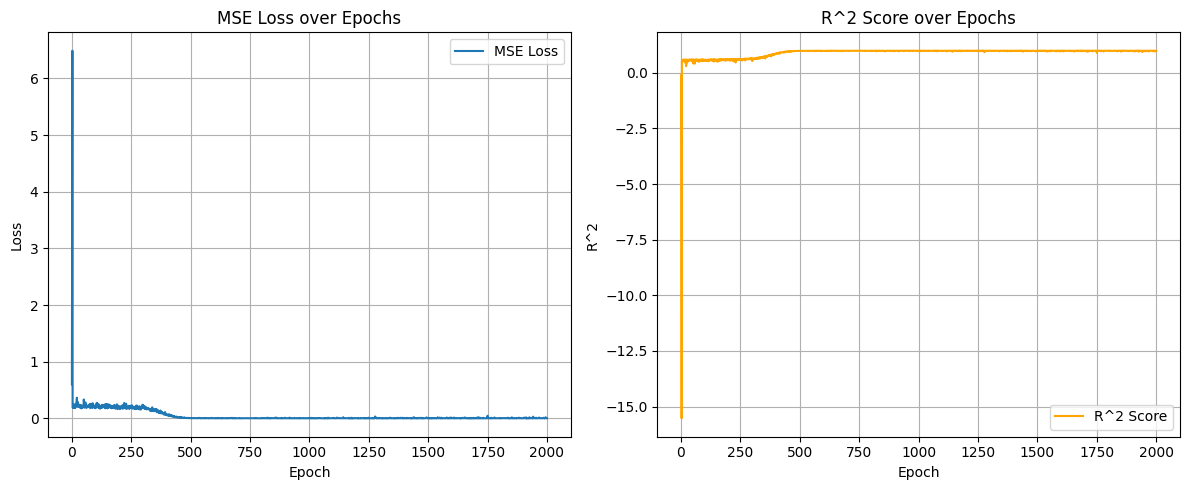

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 2001), losses, label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MSE Loss over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 2001), r2_scores, label='R^2 Score', color='orange')
plt.xlabel('Epoch')
plt.ylabel('R^2')
plt.title('R^2 Score over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<p class="task" id="5"></p>

5\. Повторите решение задач 1-2, изменив функцию потерь. Обучите модель, используя три функции потерь: `MSELoss`, `L1Loss` и `HuberLoss` - и выведите на одном графике динамику изменения метрики $R^2$ по эпохам для каждой модели в процессе обучения. Добавьте подписи полученных кривых.

- [ ] Проверено на семинаре

In [ ]:
X = th.linspace(0, 1, 100).view(-1, 1)
y = th.sin(2 * th.pi * X) + 0.1 * th.rand(X.size())

In [ ]:
n_features = X.size()[1]
n_hidden = 100
n_out = 1
learning_rate = 0.01
n_epoch = 2000
batch_size = 32

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

loss_functions = {
    'MSELoss': nn.MSELoss(),
    'L1Loss': nn.L1Loss(),
    'HuberLoss': nn.HuberLoss()
}

r2_histories = {}
loss_histories = {}

for loss_name, loss_fn in loss_functions.items():
    model = SineModel(n_features, n_hidden, n_out)
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    mean_loss = MeanMetric()
    r2_score = R2Score()
    r2_list = []
    loss_list = []

    model.train()
    for epoch in range(n_epoch):
        mean_loss.reset()

        for batch_X, batch_y in dataloader:
            y_pred = model(batch_X)
            loss = loss_fn(y_pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mean_loss.update(loss.item())

        model.eval()
        with torch.no_grad():
            y_pred_full = model(X)
            r2 = r2_score(y_pred_full, y)
            r2_list.append(r2.item())
            loss_list.append(mean_loss.compute().item())

        model.train()
        if (epoch + 1) % 200 == 0:
            print(f'{loss_name} (Задание 1) Эпоха [{epoch+1}/{n_epoch}], Потеря: {mean_loss.compute().item():.6f}, R²: {r2.item():.6f}')

    r2_histories[loss_name] = r2_list
    loss_histories[loss_name] = loss_list

    model.eval()
    with torch.no_grad():
        y_pred_f = model(X)
        final_r2 = r2_score(y_pred_f, y)
        print(f'{loss_name} (Задание 1) Финальный R²: {final_r2.item():.6f}')

MSELoss (Задание 1) Эпоха [200/2000], Потеря: 0.160283, R²: 0.654711
MSELoss (Задание 1) Эпоха [400/2000], Потеря: 0.130036, R²: 0.725290
MSELoss (Задание 1) Эпоха [600/2000], Потеря: 0.119718, R²: 0.728451
MSELoss (Задание 1) Эпоха [800/2000], Потеря: 0.095202, R²: 0.822185
MSELoss (Задание 1) Эпоха [1000/2000], Потеря: 0.066752, R²: 0.852952
MSELoss (Задание 1) Эпоха [1200/2000], Потеря: 0.065679, R²: 0.895535
MSELoss (Задание 1) Эпоха [1400/2000], Потеря: 0.038884, R²: 0.919361
MSELoss (Задание 1) Эпоха [1600/2000], Потеря: 0.025267, R²: 0.940394
MSELoss (Задание 1) Эпоха [1800/2000], Потеря: 0.022484, R²: 0.954023
MSELoss (Задание 1) Эпоха [2000/2000], Потеря: 0.014957, R²: 0.965546
MSELoss (Задание 1) Финальный R²: 0.965546
L1Loss (Задание 1) Эпоха [200/2000], Потеря: 0.380507, R²: 0.599923
L1Loss (Задание 1) Эпоха [400/2000], Потеря: 0.339270, R²: 0.653046
L1Loss (Задание 1) Эпоха [600/2000], Потеря: 0.262540, R²: 0.764877
L1Loss (Задание 1) Эпоха [800/2000], Потеря: 0.290848, R²

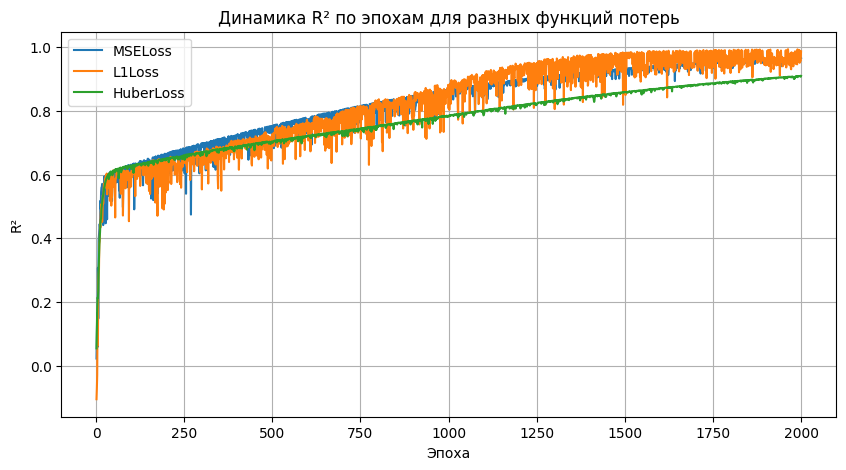

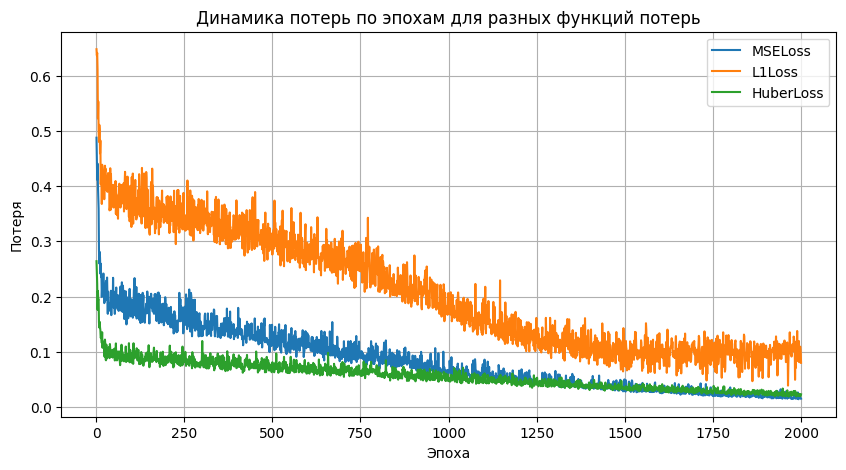

In [ ]:
plt.figure(figsize=(10, 5))
for loss_name, r2_list in r2_histories.items():
    plt.plot(range(1, n_epoch + 1), r2_list, label=loss_name)
plt.xlabel('Эпоха')
plt.ylabel('R²')
plt.title('Динамика R² по эпохам для разных функций потерь')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
for loss_name, loss_list in loss_histories.items():
    plt.plot(range(1, n_epoch + 1), loss_list, label=loss_name)
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.title('Динамика потерь по эпохам для разных функций потерь')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
learning_rate2 = 0.1
r2_histories2 = {}
loss_histories2 = {}

for loss_name, loss_fn in loss_functions.items():
    model = nn.Sequential(nn.Linear(1, 50), nn.Tanh(), nn.Linear(50, 1))
    optimizer = optim.SGD(model.parameters(), lr=learning_rate2)

    mean_loss = MeanMetric()
    r2_score = R2Score()
    r2_list = []
    loss_list = []

    model.train()
    for epoch in range(n_epoch):
        mean_loss.reset()

        for batch_X, batch_y in dataloader:
            y_pred = model(batch_X)
            loss = loss_fn(y_pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mean_loss.update(loss.item())

        model.eval()
        with torch.no_grad():
            y_pred_full = model(X)
            r2 = r2_score(y_pred_full, y)
            r2_list.append(r2.item())
            loss_list.append(mean_loss.compute().item())

        model.train()
        if (epoch + 1) % 200 == 0:
            print(f'{loss_name} (Задание 2) Эпоха [{epoch+1}/{n_epoch}], Потеря: {mean_loss.compute().item():.6f}, R²: {r2.item():.6f}')

    r2_histories2[loss_name] = r2_list
    loss_histories2[loss_name] = loss_list

    model.eval()
    with torch.no_grad():
        y_pred_f = model(X)
        final_r2 = r2_score(y_pred_f, y)
        print(f'{loss_name} (Задание 2) Финальный R²: {final_r2.item():.6f}')


MSELoss (Задание 2) Эпоха [200/2000], Потеря: 0.207879, R²: 0.601195
MSELoss (Задание 2) Эпоха [400/2000], Потеря: 0.179068, R²: 0.691355
MSELoss (Задание 2) Эпоха [600/2000], Потеря: 0.006491, R²: 0.980098
MSELoss (Задание 2) Эпоха [800/2000], Потеря: 0.003557, R²: 0.985127
MSELoss (Задание 2) Эпоха [1000/2000], Потеря: 0.016335, R²: 0.970334
MSELoss (Задание 2) Эпоха [1200/2000], Потеря: 0.004233, R²: 0.992891
MSELoss (Задание 2) Эпоха [1400/2000], Потеря: 0.004197, R²: 0.987430
MSELoss (Задание 2) Эпоха [1600/2000], Потеря: 0.004807, R²: 0.986290
MSELoss (Задание 2) Эпоха [1800/2000], Потеря: 0.004865, R²: 0.993945
MSELoss (Задание 2) Эпоха [2000/2000], Потеря: 0.005090, R²: 0.986478
MSELoss (Задание 2) Финальный R²: 0.986478
L1Loss (Задание 2) Эпоха [200/2000], Потеря: 0.365122, R²: 0.577427
L1Loss (Задание 2) Эпоха [400/2000], Потеря: 0.411457, R²: -0.067619
L1Loss (Задание 2) Эпоха [600/2000], Потеря: 0.202933, R²: 0.913177
L1Loss (Задание 2) Эпоха [800/2000], Потеря: 0.131679, R

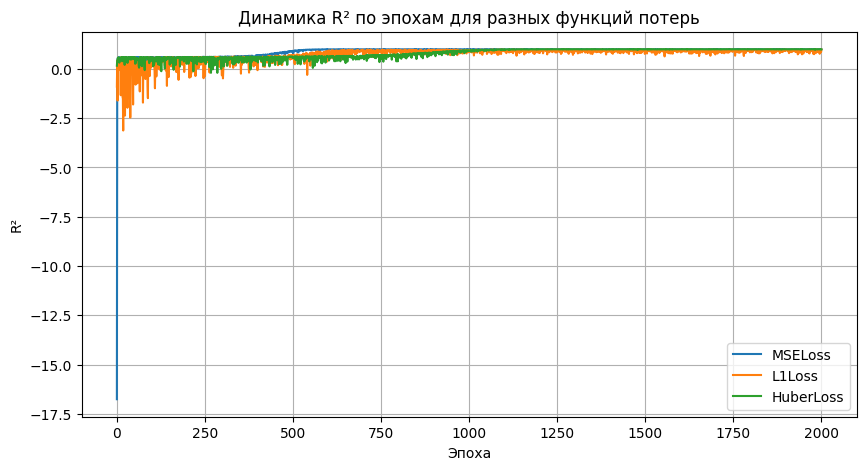

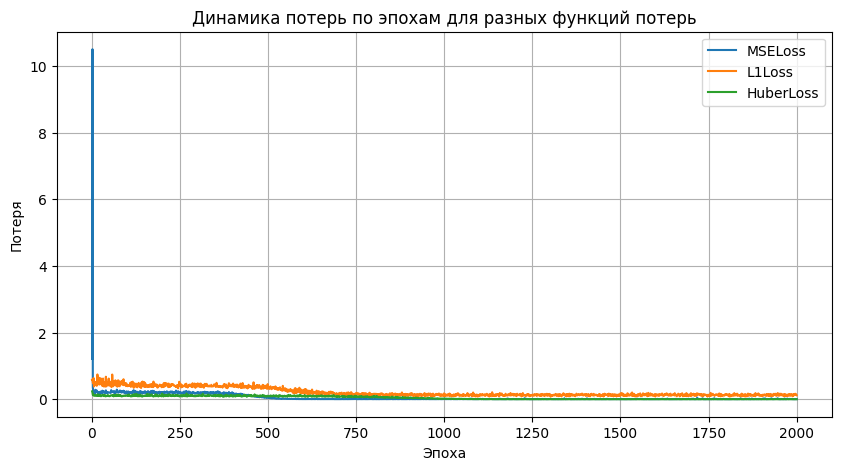

In [ ]:
plt.figure(figsize=(10, 5))
for loss_name, r2_list in r2_histories2.items():
    plt.plot(range(1, n_epoch + 1), r2_list, label=loss_name)
plt.xlabel('Эпоха')
plt.ylabel('R²')
plt.title('Динамика R² по эпохам для разных функций потерь')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for loss_name, loss_list in loss_histories2.items():
    plt.plot(range(1, n_epoch + 1), loss_list, label=loss_name)
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.title('Динамика потерь по эпохам для разных функций потерь')
plt.legend()
plt.grid(True)
plt.show()

<p class="task" id="6"></p>

6\. Повторите решение задач 1-2, разделив датасет на обучающую и тестовую выборку в соотношении 80% на 20%. Обучите модель. Для тестовой выборки посчитайте и выведите на экран значения метрик:

- MAE;
- MAPE;
- MSE;
- MSLE (MeanSquaredLogError).


- [ ] Проверено на семинаре

In [ ]:
from torchmetrics import MeanAbsoluteError, MeanAbsolutePercentageError, MeanSquaredError, MeanSquaredLogError
from sklearn.model_selection import train_test_split

In [ ]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
n_features = X.size()[1]
n_hidden = 100
n_out = 1
learning_rate = 0.01
n_epoch = 2000
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mae_metric = MeanAbsoluteError()
mape_metric = MeanAbsolutePercentageError()
mse_metric = MeanSquaredError()
msle_metric = MeanSquaredLogError()

def compute_metrics(model, X_test, y_test):
    model.eval()
    with th.no_grad():
        y_pred = model(X_test)
        mae = mae_metric(y_pred, y_test).item()
        mape = mape_metric(y_pred, y_test).item()
        mse = mse_metric(y_pred, y_test).item()
        msle = msle_metric(y_pred, y_test).item()
    return mae, mape, mse, msle

In [ ]:
model1 = SineModel(n_features, n_hidden, n_out)
optimizer1 = optim.SGD(model1.parameters(), lr=learning_rate)
mse_loss = nn.MSELoss()
mean_loss = MeanMetric()

predict1 = []
losses1 = []
s_epochs = [0, n_epoch // 2, n_epoch - 1]

model1.train()
for epoch in range(n_epoch):
    mean_loss.reset()

    for batch_X, batch_y in train_loader:
        y_pred = model1(batch_X)
        loss = mse_loss(y_pred, batch_y)

        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()

        mean_loss.update(loss.item())

    losses1.append(mean_loss.compute().item())

    if epoch in s_epochs:
        model1.eval()
        with th.no_grad():
            y_pred = model1(X_test)
            predict1.append((epoch, y_pred.clone()))
        model1.train()

    if (epoch + 1) % 200 == 0:
        print(f'Архитектура 1, Эпоха [{epoch+1}/{n_epoch}], Потеря: {mean_loss.compute().item():.6f}')

mae, mape, mse, msle = compute_metrics(model1, X_test, y_test)
print(f'MAE: {mae:.6f}')
print(f'MAPE: {mape:.6f}')
print(f'MSE: {mse:.6f}')
print(f'MSLE: {msle:.6f}')

Архитектура 1, Эпоха [200/2000], Потеря: 0.173452
Архитектура 1, Эпоха [400/2000], Потеря: 0.158584
Архитектура 1, Эпоха [600/2000], Потеря: 0.124722
Архитектура 1, Эпоха [800/2000], Потеря: 0.105530
Архитектура 1, Эпоха [1000/2000], Потеря: 0.096156
Архитектура 1, Эпоха [1200/2000], Потеря: 0.081023
Архитектура 1, Эпоха [1400/2000], Потеря: 0.074783
Архитектура 1, Эпоха [1600/2000], Потеря: 0.060239
Архитектура 1, Эпоха [1800/2000], Потеря: 0.047605
Архитектура 1, Эпоха [2000/2000], Потеря: 0.043732
MAE: 0.194427
MAPE: 2.639094
MSE: 0.049533
MSLE: 1.117319


In [ ]:
learning_rate2 = 0.1
model2 = nn.Sequential(nn.Linear(1, 50), nn.Tanh(), nn.Linear(50, 1))
optimizer2 = optim.SGD(model2.parameters(), lr=learning_rate2)

predict2 = []
losses2 = []

model2.train()
for epoch in range(n_epoch):
    mean_loss.reset()

    for batch_X, batch_y in train_loader:
        y_pred = model2(batch_X)
        loss = mse_loss(y_pred, batch_y)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        mean_loss.update(loss.item())

    losses2.append(mean_loss.compute().item())

    if epoch in s_epochs:
        model2.eval()
        with torch.no_grad():
            y_pred = model2(X_test)
            predict2.append((epoch, y_pred.clone()))
        model2.train()

    if (epoch + 1) % 200 == 0:
        print(f'Архитектура 2, Эпоха [{epoch+1}/{n_epoch}], Потеря: {mean_loss.compute().item():.6f}')

mae, mape, mse, msle = compute_metrics(model2, X_test, y_test)
print(f'\nАрхитектура 2 (Тестовая выборка):')
print(f'MAE: {mae:.6f}')
print(f'MAPE: {mape:.6f}')
print(f'MSE: {mse:.6f}')
print(f'MSLE: {msle:.6f}')

Архитектура 2, Эпоха [200/2000], Потеря: 0.195674
Архитектура 2, Эпоха [400/2000], Потеря: 0.136238
Архитектура 2, Эпоха [600/2000], Потеря: 0.007785
Архитектура 2, Эпоха [800/2000], Потеря: 0.017470
Архитектура 2, Эпоха [1000/2000], Потеря: 0.006146
Архитектура 2, Эпоха [1200/2000], Потеря: 0.003981
Архитектура 2, Эпоха [1400/2000], Потеря: 0.005247
Архитектура 2, Эпоха [1600/2000], Потеря: 0.005788
Архитектура 2, Эпоха [1800/2000], Потеря: 0.007378
Архитектура 2, Эпоха [2000/2000], Потеря: 0.003170

Архитектура 2 (Тестовая выборка):
MAE: 0.046909
MAPE: 0.628767
MSE: 0.003328
MSLE: 0.116505
